In [1]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Загрузка выборки



In [2]:
horse_colic = fetch_ucirepo(id=47)

X = horse_colic.data.features.copy()
y = horse_colic.data.targets.copy()

target_col = y.columns[0]
df = pd.concat([X, y], axis=1)

print("Название датасета:", horse_colic.metadata.name)
print("Размер выборки:", df.shape)
print("Целевая переменная:", target_col)

df.head(10)

Название датасета: Horse Colic
Размер выборки: (368, 28)
Целевая переменная: surgical_lesion


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,peristalsis,abdominal_distension,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_examination_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,4.0,4.0,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,4.0,2.0,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,4.0,4.0,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2
5,2.0,1,528355,NaN,NaN,NaN,2.0,1.0,3.0,1.0,2.0,3.0,2.0,2.0,1.0,NaN,3.0,3.0,NaN,NaN,NaN,NaN,1.0,0,0,0,2,2
6,1.0,1,526802,37.9,48.0,16.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,1.0,1.0,NaN,3.0,5.0,37.0,7.0,NaN,NaN,1.0,3124,0,0,2,1
7,1.0,1,529607,NaN,60.0,NaN,3.0,NaN,NaN,1.0,NaN,4.0,2.0,2.0,1.0,NaN,3.0,4.0,44.0,8.3,NaN,NaN,2.0,2208,0,0,2,1
8,2.0,1,530051,NaN,80.0,36.0,3.0,4.0,3.0,1.0,4.0,4.0,4.0,2.0,1.0,NaN,3.0,5.0,38.0,6.2,NaN,NaN,3.0,3205,0,0,2,1
9,2.0,9,5299629,38.3,90.0,NaN,1.0,NaN,1.0,1.0,5.0,3.0,1.0,2.0,1.0,NaN,3.0,NaN,40.0,6.2,1.0,2.2,1.0,0,0,0,1,2


## 2. Описание признаков

In [3]:
variables_info = horse_colic.variables
variables_info

,name,role,type,demographic,description,units,missing_values
0,surgery,Feature,Integer,None,None,None,yes
1,age,Feature,Integer,Age,None,None,no
2,hospital_number,Feature,Integer,None,None,None,no
3,rectal_temperature,Feature,Continuous,None,None,None,yes
4,pulse,Feature,Integer,None,None,None,yes
5,respiratory_rate,Feature,Integer,None,None,None,yes
6,temperature_of_extremities,Feature,Integer,None,None,None,yes
7,peripheral_pulse,Feature,Integer,None,None,None,yes
8,mucous_membranes,Feature,Integer,None,None,None,yes
9,capillary_refill_time,Feature,Integer,None,None,None,yes


In [4]:
print("Первые строки таблицы:")
display(df.head())

print("\nТипы данных:")
display(df.dtypes.to_frame(name="dtype"))

print("\nКоличество пропусков:")
display(df.isna().sum().to_frame(name="missing_count"))

print("\nКоличество уникальных значений:")
display(df.nunique().to_frame(name="unique_count"))


Первые строки таблицы:


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,peristalsis,abdominal_distension,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_examination_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,4.0,4.0,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,4.0,2.0,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,4.0,4.0,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2



Типы данных:


,dtype
surgery,float64
age,int64
hospital_number,int64
rectal_temperature,float64
pulse,float64
respiratory_rate,float64
temperature_of_extremities,float64
peripheral_pulse,float64
mucous_membranes,float64
capillary_refill_time,float64



Количество пропусков:


,missing_count
surgery,2
age,0
hospital_number,0
rectal_temperature,69
pulse,26
respiratory_rate,71
temperature_of_extremities,65
peripheral_pulse,83
mucous_membranes,48
capillary_refill_time,38



Количество уникальных значений:


,unique_count
surgery,2
age,2
hospital_number,346
rectal_temperature,40
pulse,54
respiratory_rate,40
temperature_of_extremities,4
peripheral_pulse,4
mucous_membranes,6
capillary_refill_time,3


## 3. Описательная статистика

In [5]:
print("Описательная статистика:")
descriptive_stats = df.describe(include="all").T
descriptive_stats

Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
surgery,366.0,1.415301e+00,4.934484e-01,1.0,1.00,1.0,2.0,2.0
age,368.0,1.608696e+00,2.123985e+00,1.0,1.00,1.0,1.0,9.0
hospital_number,368.0,1.112334e+06,1.560122e+06,514279.0,528915.25,530299.0,534727.5,5305629.0
rectal_temperature,299.0,3.813445e+01,7.116839e-01,35.4,37.80,38.1,38.5,40.8
pulse,342.0,7.075731e+01,2.808987e+01,30.0,48.00,60.0,88.0,184.0
respiratory_rate,297.0,3.052189e+01,1.766965e+01,8.0,18.00,28.0,36.0,96.0
temperature_of_extremities,303.0,2.356436e+00,1.041371e+00,1.0,1.00,3.0,3.0,4.0
peripheral_pulse,285.0,1.961404e+00,1.052454e+00,1.0,1.00,1.0,3.0,4.0
mucous_membranes,320.0,2.834375e+00,1.591732e+00,1.0,1.00,3.0,4.0,6.0
capillary_refill_time,330.0,1.303030e+00,4.732895e-01,1.0,1.00,1.0,2.0,3.0


In [6]:
modes = {}
for column in df.columns:
    modes[column] = df[column].mode(dropna=True).iloc[0]

for column, mode in modes.items():
    print(f"Мода для '{column}': {mode}")


Мода для 'surgery': 1.0
Мода для 'age': 1
Мода для 'hospital_number': 527544
Мода для 'rectal_temperature': 38.0
Мода для 'pulse': 48.0
Мода для 'respiratory_rate': 20.0
Мода для 'temperature_of_extremities': 3.0
Мода для 'peripheral_pulse': 1.0
Мода для 'mucous_membranes': 1.0
Мода для 'capillary_refill_time': 1.0
Мода для 'pain': 3.0
Мода для 'peristalsis': 3.0
Мода для 'abdominal_distension': 1.0
Мода для 'nasogastric_tube': 2.0
Мода для 'nasogastric_reflux': 1.0
Мода для 'nasogastric_reflux_ph': 2.0
Мода для 'rectal_examination_feces': 4.0
Мода для 'abdomen': 5.0
Мода для 'packed_cell_volume': 37.0
Мода для 'total_protein': 7.5
Мода для 'abdominocentesis_appearance': 2.0
Мода для 'abdominocentesis_total_protein': 2.0
Мода для 'outcome': 1.0
Мода для 'lesion_site': 0
Мода для 'lesion_type': 0
Мода для 'lesion_subtype': 0
Мода для 'cp_data': 2
Мода для 'surgical_lesion': 1


In [7]:
for column in df.columns:
    freq_table = pd.DataFrame({
        "count": df[column].value_counts(dropna=False),
        "percent": df[column].value_counts(normalize=True, dropna=False) * 100
    })
    display(freq_table.round(2))


,count,percent
surgery,,
1.0,214,58.15
2.0,152,41.30
NaN,2,0.54


,count,percent
age,,
1,340,92.39
9,28,7.61


,count,percent
hospital_number,,
528151,2,0.54
5274919,2,0.54
527916,2,0.54
529424,2,0.54
529461,2,0.54
...,...,...
529840,1,0.27
530360,1,0.27
534579,1,0.27


,count,percent
rectal_temperature,,
NaN,69,18.75
38.0,34,9.24
38.3,23,6.25
38.2,23,6.25
38.5,21,5.71
37.8,21,5.71
37.5,16,4.35
38.1,15,4.08
38.4,14,3.80


,count,percent
pulse,,
48.0,35,9.51
60.0,33,8.97
NaN,26,7.07
40.0,21,5.71
44.0,16,4.35
88.0,15,4.08
42.0,15,4.08
52.0,14,3.80
100.0,13,3.53


...

,count,percent
lesion_site,,
0,67,18.21
3111,41,11.14
3205,35,9.51
2208,23,6.25
2205,17,4.62
...,...,...
2305,1,0.27
5205,1,0.27
4122,1,0.27


,count,percent
lesion_type,,
0,358,97.28
3111,3,0.82
3205,2,0.54
1400,1,0.27
7111,1,0.27
6112,1,0.27
3112,1,0.27
2208,1,0.27


,count,percent
lesion_subtype,,
0,367,99.73
2209,1,0.27


,count,percent
cp_data,,
2,244,66.3
1,124,33.7


,count,percent
surgical_lesion,,
1,232,63.04
2,136,36.96


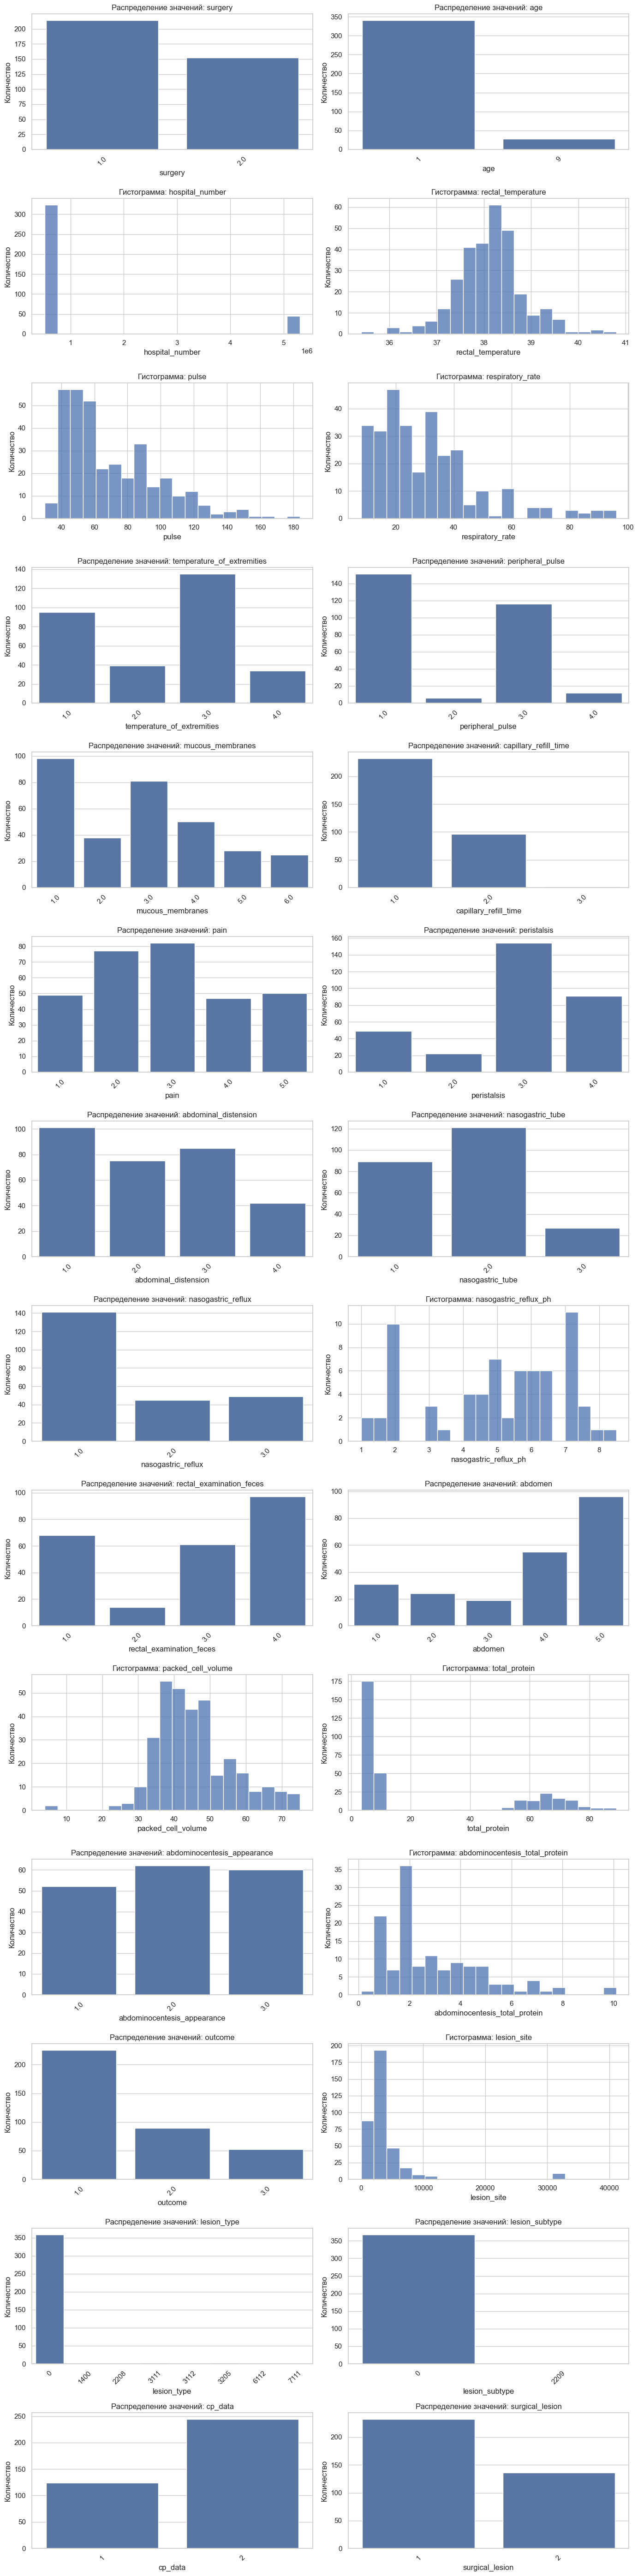

In [8]:
columns_for_plot = df.columns

n_cols = 2
n_rows = int(np.ceil(len(columns_for_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, columns_for_plot):
    if df[column].nunique() <= 20:
        sns.countplot(data=df, x=column, ax=ax)
        ax.set_title(f"Распределение значений: {column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Количество")
        ax.tick_params(axis="x", rotation=45)
    else:
        sns.histplot(data=df, x=column, ax=ax, bins=20)
        ax.set_title(f"Гистограмма: {column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Количество")

for ax in axes[len(columns_for_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Кодирование категориальных признаков



In [9]:
label_encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded.head()


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,peristalsis,abdominal_distension,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_examination_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,1,0,196,23,38,14,2,2,6,1,4,3,3,3,3,24,2,4,23,70,3,44,1,4,0,0,1,1
1,0,0,306,30,49,7,4,4,3,0,2,3,1,3,3,24,3,1,28,79,1,11,2,16,0,0,1,1
2,1,0,213,21,23,11,0,0,2,0,2,2,0,3,3,24,0,0,9,34,3,44,0,0,0,0,0,1
3,0,1,115,29,17,35,3,0,5,1,1,3,3,0,1,9,2,5,26,49,2,36,1,16,0,0,0,0
4,1,0,206,11,1,18,4,4,5,1,5,4,4,3,3,24,4,5,52,51,3,44,1,43,0,0,1,1


## 5. Матрица корреляции

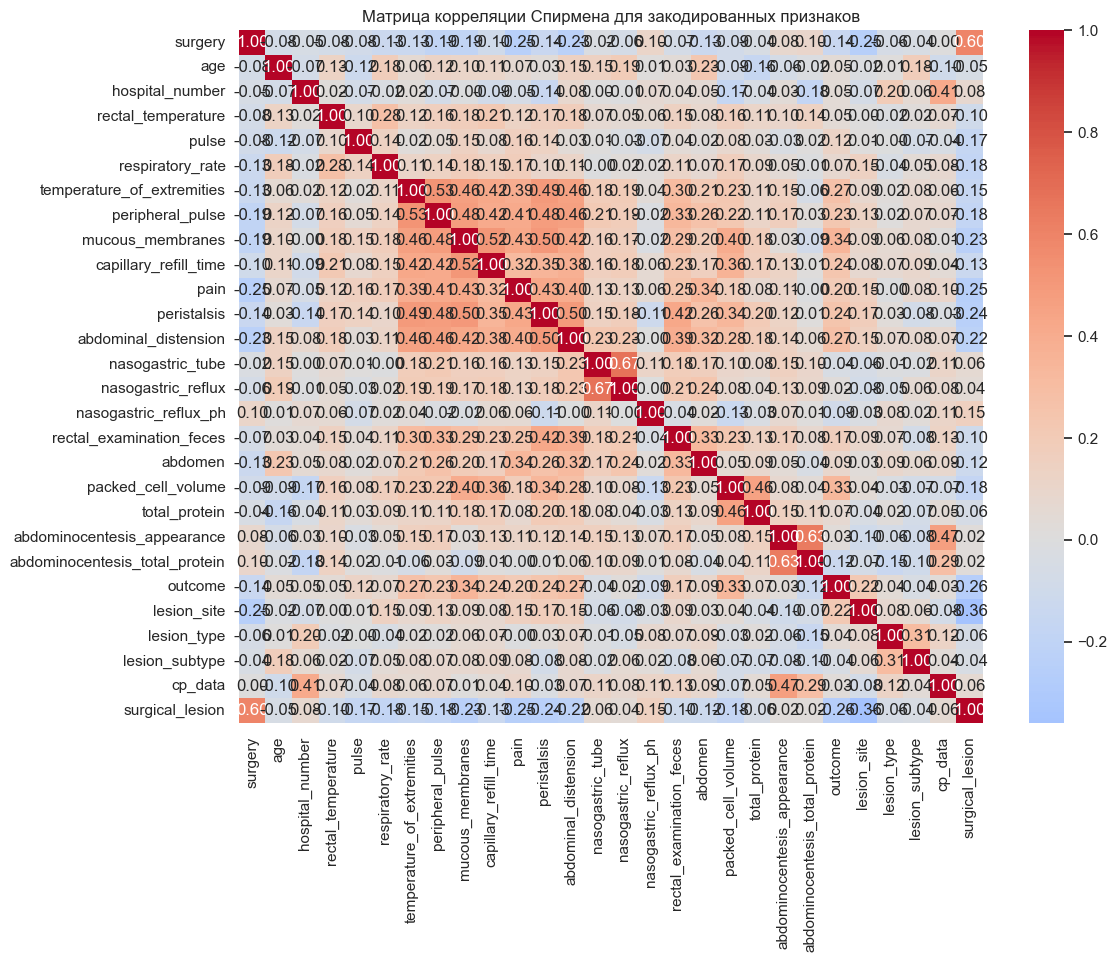

In [10]:
label_encoders = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

df_encoded.head()

correlation_matrix = df_encoded.corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Матрица корреляции Спирмена для закодированных признаков")
plt.show()

## 6. Взаимосвязь входных показателей с выходом


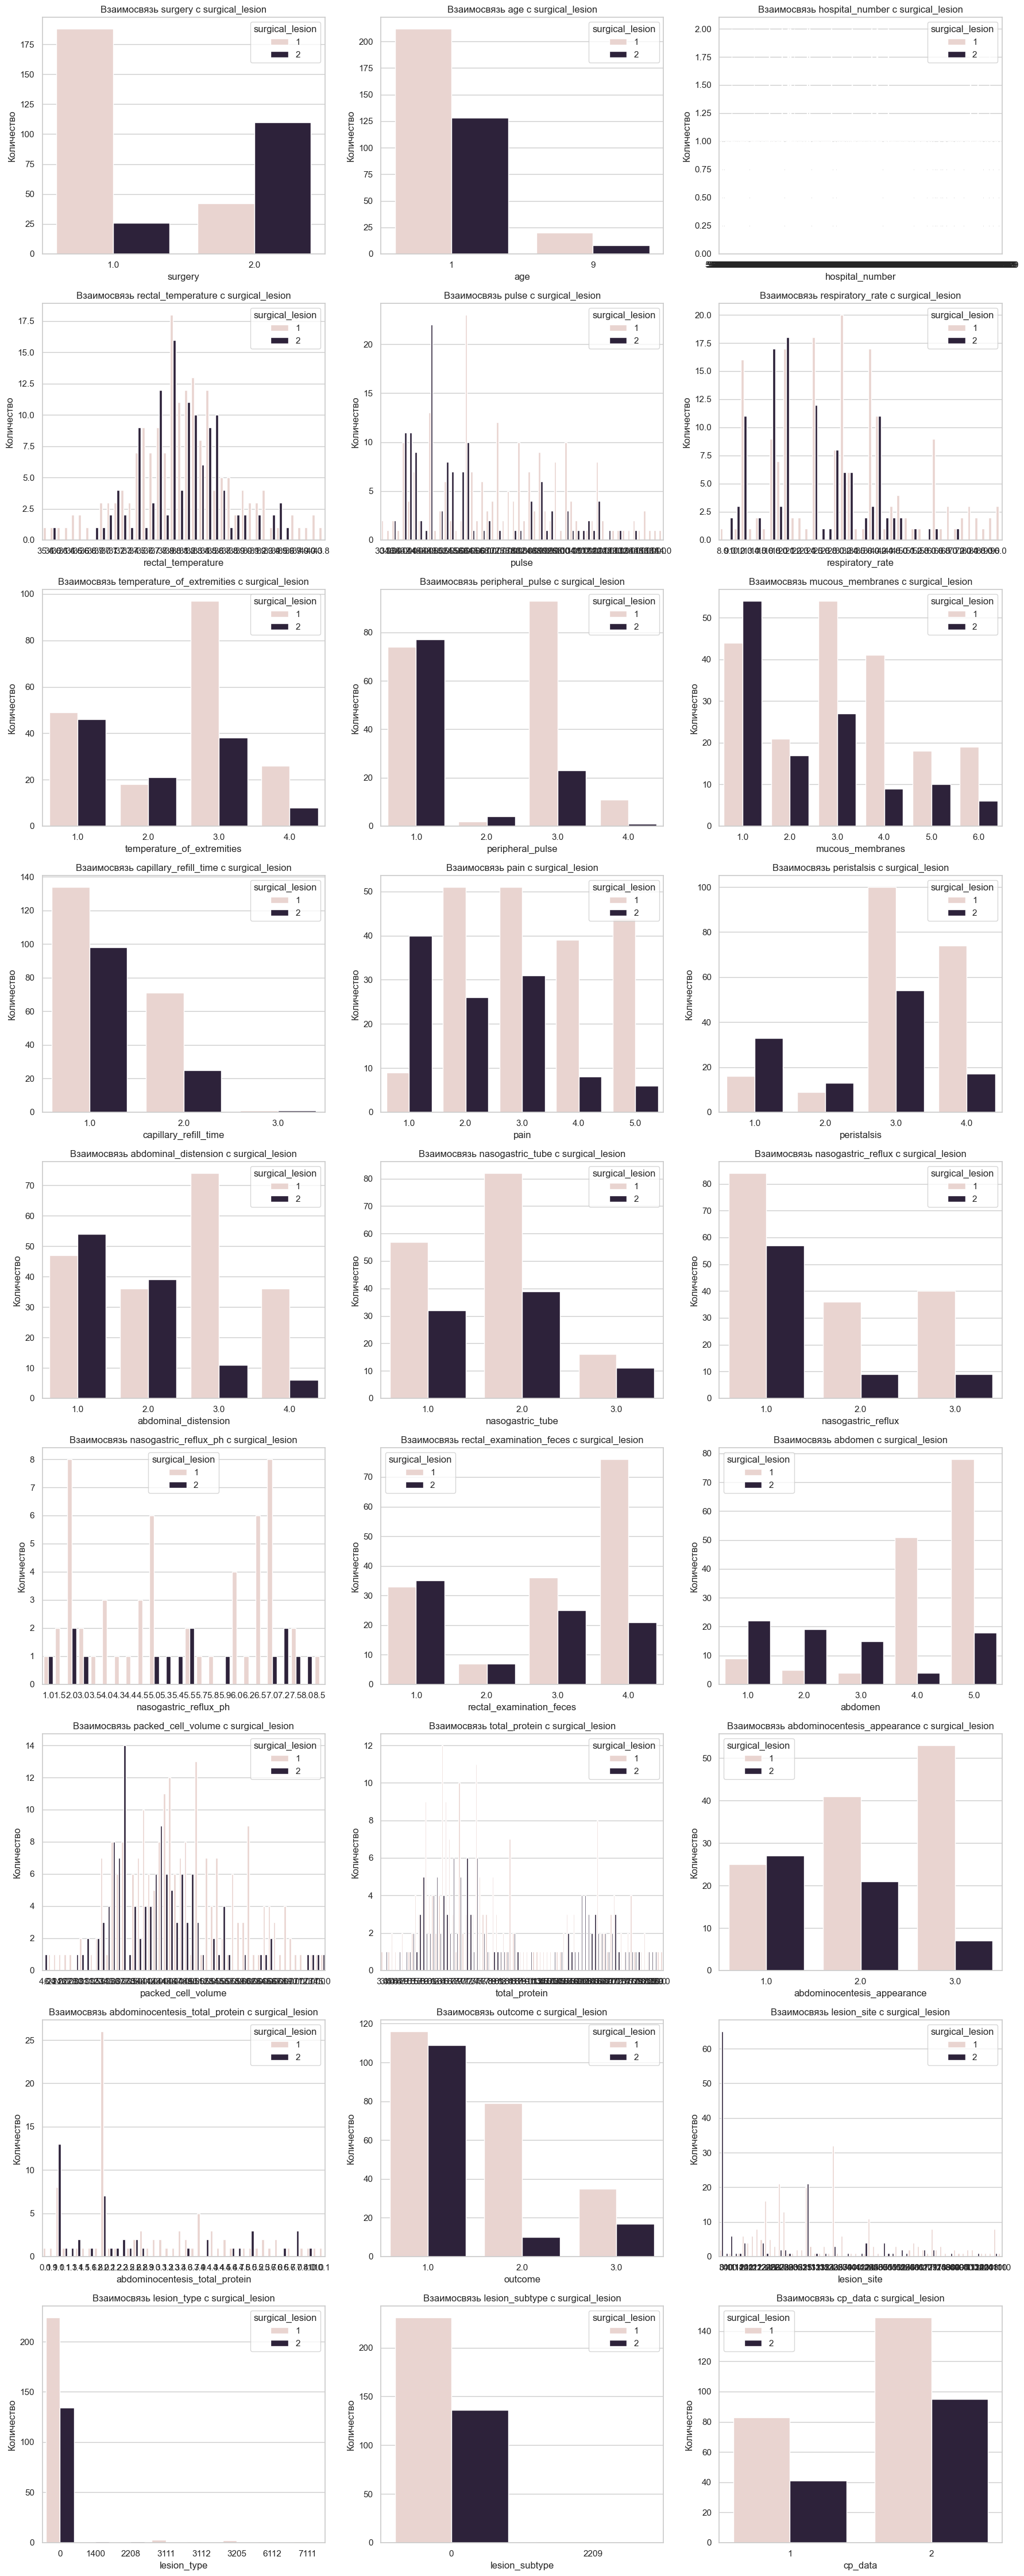

In [11]:
input_features = [col for col in df.columns if col != target_col]

n_cols = 3
n_rows = int(np.ceil(len(input_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, input_features):
    order = sorted(df[col].dropna().unique())
    sns.countplot(data=df, x=col, hue=target_col, order=order, ax=ax)
    ax.set_title(f"Взаимосвязь {col} с {target_col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество")

for ax in axes[len(input_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [12]:
for col in input_features:
    print(f"\nДоля классов '{target_col}' внутри категорий признака '{col}', %:")
    cross_tab_percent = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    display(cross_tab_percent.round(2))



Доля классов 'surgical_lesion' внутри категорий признака 'surgery', %:


surgical_lesion,1,2
surgery,,
1.0,87.85,12.15
2.0,27.63,72.37



Доля классов 'surgical_lesion' внутри категорий признака 'age', %:


surgical_lesion,1,2
age,,
1,62.35,37.65
9,71.43,28.57



Доля классов 'surgical_lesion' внутри категорий признака 'hospital_number', %:


...

surgical_lesion,1,2
lesion_type,,
0,62.57,37.43
1400,0.00,100.00
2208,0.00,100.00
3111,100.00,0.00
3112,100.00,0.00
3205,100.00,0.00
6112,100.00,0.00
7111,100.00,0.00



Доля классов 'surgical_lesion' внутри категорий признака 'lesion_subtype', %:


surgical_lesion,1,2
lesion_subtype,,
0,62.94,37.06
2209,100.00,0.00



Доля классов 'surgical_lesion' внутри категорий признака 'cp_data', %:


surgical_lesion,1,2
cp_data,,
1,66.94,33.06
2,61.07,38.93
